<a href="https://colab.research.google.com/github/Quynhanh746/Python-2026-L1/blob/main/PA6_2410127.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1.A: Matrix creation, indexing & slicing

In [32]:
import numpy as np
A = np.array([
    [4.0, 2.0, 1.0],
    [9.0, 3.0, 1.0],
    [25.0, 5.0, 1.0]
])
b = np.array([0.693, 1.098, 1.609])
print("Shape of A:", A.shape)
print("Shape of b:", b.shape)

last_row = A[-1, :]
first_col = A[:, 0]
print("Last row of A:", last_row)
print("First column of A:", first_col)

A1 = A
A1[0, 0] = 99.0
print("A1[0,0] =", A1[0, 0])
print("A[0,0] =", A[0, 0])

A[0, 0] = 4.0
Acopy = A.copy()
Acopy[0, 0] = 99.0
print("Acopy[0,0] =", Acopy[0, 0])
print("A[0,0] =", A[0, 0])

Shape of A: (3, 3)
Shape of b: (3,)
Last row of A: [25.  5.  1.]
First column of A: [ 4.  9. 25.]
A1[0,0] = 99.0
A[0,0] = 99.0
Acopy[0,0] = 99.0
A[0,0] = 4.0


#Task 1.B: Multiplication operators (@ vs *)


In [33]:
B = A.T
C = A * B
D = A @ B
print("C[0,1] (element-wise):", C[0, 1])
print("D[0,1] (matrix product):", D[0, 1])

C[0,1] (element-wise): 18.0
D[0,1] (matrix product): 43.0


#Task 1.C: Zero-pivot & small-pivot numerical hazards

In [34]:
# 1. Zero-pivot
A_zero = np.array([[0.0, 1.0], [1.0, 1.0]])
try:
    l_21 = A_zero[1, 0] / A_zero[0, 0]
except ZeroDivisionError as e:
    print("Zero-pivot Error:", e)

# 2. Small-pivot system
eps = 1e-16
print("1.0 - 1e16 trong float64:", 1.0 - 1e16)
print("2.0 - 1e16 trong float64:", 2.0 - 1e16)

1.0 - 1e16 trong float64: -1e+16
2.0 - 1e16 trong float64: -9999999999999998.0


/tmp/ipykernel_1012/1056230122.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  l_21 = A_zero[1, 0] / A_zero[0, 0]


#Task 2

In [35]:
def backward_substitution(U, d):
    n = len(d)
    x = np.zeros(n)
    x[-1] = d[-1] / U[-1, -1]
    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - np.sum(U[i, i + 1:] * x[i + 1:])) / U[i, i]
    return x

def solve_naive(A, b):
    A1 = A.copy()
    b1 = b.copy()
    n = len(b)

    for k in range(n - 1):
        if abs(A1[k, k]) < 1e-15:
            raise ZeroDivisionError(f"Almost zero pivot at index ({k}, {k})")
        for i in range(k + 1, n):
            m_ik = A1[i, k] / A1[k, k]
            A1[i, k:] -= m_ik * A1[k, k:]
            b1[i] -= m_ik * b1[k]

    x = backward_substitution(A1, b1)
    return x, A1

# Chạy kiểm thử bài toán Part 1
x_naive, U_naive = solve_naive(A, b)
r = b - A @ x_naive
r_norm = np.max(np.abs(r))

print("m_{1,0}:", A[1, 0] / A[0, 0])
print("Ma trận U thu được:\n", U_naive)
print("Nghiệm x:", x_naive)
print("Residual norm ||r||_inf:", r_norm)

m_{1,0}: 2.25
Ma trận U thu được:
 [[ 4.    2.    1.  ]
 [ 0.   -1.5  -1.25]
 [ 0.    0.    1.  ]]
Nghiệm x: [-0.04983333  0.65416667 -0.416     ]
Residual norm ||r||_inf: 4.440892098500626e-16


# Part 3:

In [36]:
import numpy as np

# 1. Định nghĩa hàm solve_pivoting (Part 3.A)
def solve_pivoting(A, b):
    A1 = A.copy()
    b1 = b.copy()
    n = len(b)

    for k in range(n - 1):
        # Bước 1: Tìm chỉ số hàng p >= k có giá trị tuyệt đối lớn nhất tại cột k
        p = np.argmax(np.abs(A1[k:n, k])) + k

        # Bước 2: Hoán đổi hàng k và hàng p nếu p > k
        if p > k:
            A1[[k, p], :] = A1[[p, k], :].copy()
            b1[[k, p]] = b1[[p, k]].copy()

        # Bước 3: Khử Gauss tiến
        for i in range(k + 1, n):
            m_ik = A1[i, k] / A1[k, k]
            A1[i, k:] -= m_ik * A1[k, k:]
            b1[i] -= m_ik * b1[k]

    # Bước 4: Thế ngược
    x = backward_substitution(A1, b1)
    return x

# 2. Áp dụng vào hệ Small-Pivot (Part 3.B)
A_eps = np.array([[1e-16, 1.0], [1.0, 1.0]])
b_eps = np.array([1.0, 2.0])

# Thử chạy solve_naive và bắt lỗi ZeroDivisionError
try:
    x_naive_eps = solve_naive(A_eps, b_eps)
    print("x_naive  :", x_naive_eps)
except ZeroDivisionError as e:
    print("x_naive  : Không thể giải do lỗi -", e)

# Chạy solve_pivoting
x_pivot_eps = solve_pivoting(A_eps, b_eps)
print("x_pivoted:", x_pivot_eps)

x_naive  : Không thể giải do lỗi - Almost zero pivot at index (0, 0)
x_pivoted: [1. 1.]


# Part 4:

In [37]:
def lu_factorize(A):
    n = len(A)
    L = np.identity(n, dtype=float)
    U = np.zeros_like(A, dtype=float)

    for k in range(n):
        for j in range(k, n):
            U[k, j] = A[k, j] - np.sum(L[k, :k] * U[:k, j])
        for i in range(k + 1, n):
            L[i, k] = (A[i, k] - np.sum(L[i, :k] * U[:k, k])) / U[k, k]

    return L, U

def forward_substitution(L, b):
    n = len(b)
    d = np.zeros(n, dtype=float)
    d[0] = b[0] / L[0, 0]
    for i in range(1, n):
        d[i] = b[i] - np.sum(L[i, :i] * d[:i])
    return d

def solve_lu(A, b):
    L, U = lu_factorize(A)
    d = forward_substitution(L, b)
    x = backward_substitution(U, d)
    return x

# Chạy Task 4.B
b1 = np.array([0.693, 1.098, 1.609])
b2 = np.array([2.0, 15.0, 0.0])

L, U = lu_factorize(A)
d1 = forward_substitution(L, b1)
f1 = backward_substitution(U, d1)

d2 = forward_substitution(L, b2)
f2 = backward_substitution(U, d2)

print("Matrix L:\n", L)
print("Matrix U:\n", U)
print("d1:", d1, "| f1:", f1)
print("d2:", d2, "| f2:", f2)

Matrix L:
 [[1.   0.   0.  ]
 [2.25 1.   0.  ]
 [6.25 5.   1.  ]]
Matrix U:
 [[ 4.    2.    1.  ]
 [ 0.   -1.5  -1.25]
 [ 0.    0.    1.  ]]
d1: [ 0.693   -0.46125 -0.416  ] | f1: [-0.04983333  0.65416667 -0.416     ]
d2: [  2.   10.5 -65. ] | f2: [ -6.83333333  47.16666667 -65.        ]


# Part 5:

In [38]:
import numpy as np

# Sử dụng lại các hàm lu_factorize, forward_substitution, backward_substitution đã viết ở Part 4

def invert_matrix_lu(A):
    """Tính ma trận nghịch đảo A^(-1) bằng phân rã LU"""
    n = len(A)
    L, U = lu_factorize(A)
    A_inv = np.zeros((n, n), dtype=float)

    for i in range(n):
        # Tạo vectơ đơn vị e_i
        e_i = np.zeros(n, dtype=float)
        e_i[i] = 1.0

        # 1. Giải L * d_i = e_i bằng thế tiến
        d_i = forward_substitution(L, e_i)

        # 2. Giải U * x_i = d_i bằng thế ngược để tìm cột thứ i của A_inv
        A_inv[:, i] = backward_substitution(U, d_i)

    return A_inv

def det_lu(A):
    """Tính định thức det(A) bằng phân rã LU (det(A) = tích các phần tử trên đường chéo U)"""
    L, U = lu_factorize(A)
    return np.prod(np.diag(U))

# --- Chạy thử nghiệm và xác minh cho Part 5 ---
A = np.array([
    [4.0, 2.0, 1.0],
    [9.0, 3.0, 1.0],
    [25.0, 5.0, 1.0]
])

# 1. Tính ma trận nghịch đảo
A_inv = invert_matrix_lu(A)

# 2. Xác minh A @ A_inv ≈ I
prod_check = np.round(A @ A_inv, 6)

# 3. Tính định thức
det_val = det_lu(A)
det_np = np.linalg.det(A)

print("--- PART 5 RESULTS ---")
print("1. Computed A_inv (rounded 3 decimals):\n", np.round(A_inv, 3))
print("\n2. Verification (A @ A_inv):\n", prod_check)
print("\n3. Determinant det(A) via LU:", det_val)
print("   Determinant via np.linalg.det:", det_np)

--- PART 5 RESULTS ---
1. Computed A_inv (rounded 3 decimals):
 [[ 0.333 -0.5    0.167]
 [-2.667  3.5   -0.833]
 [ 5.    -5.     1.   ]]

2. Verification (A @ A_inv):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

3. Determinant det(A) via LU: -6.0
   Determinant via np.linalg.det: -6.000000000000003


# Part 6:

In [39]:
import numpy as np

def power_method(A, max_iter=50, tol=1e-8):
    """Tìm giá trị riêng trội và vectơ riêng tương ứng bằng Power Method"""
    n = len(A)
    x = np.ones(n, dtype=float) # Vectơ dự đoán ban đầu
    lambda_old = 0.0

    print("--- POWER METHOD ITERATIONS ---")
    for k in range(max_iter):
        y = A @ x

        # Ước lượng giá trị riêng bằng phần tử có giá trị tuyệt đối lớn nhất
        lambda_new = y[np.argmax(np.abs(y))]

        # Chuẩn hóa vectơ x bằng chuẩn vô cùng (infinity norm)
        x = y / np.linalg.norm(y, np.inf)

        # In giá trị riêng ở các vòng lặp 2, 5, 10, 20
        if k + 1 in [2, 5, 10, 20]:
            print(f"Iteration {k+1:2d}: lambda = {lambda_new:.6f}")

        # Kiểm tra điều kiện hội tụ
        if abs(lambda_new - lambda_old) < tol:
            print(f"Converged at iteration {k+1}!")
            break

        lambda_old = lambda_new

    return lambda_new, x

# --- Chạy thử nghiệm cho Part 6 ---
lambda_1, v_1 = power_method(A)

print("\n--- PART 6 RESULTS ---")
print("Dominant Eigenvalue (lambda_1):", lambda_1)
print("Corresponding Eigenvector (v_1):", v_1)

--- POWER METHOD ITERATIONS ---
Iteration  2: lambda = 8.741935
Iteration  5: lambda = 10.709586
Iteration 10: lambda = 10.666083
Converged at iteration 18!

--- PART 6 RESULTS ---
Dominant Eigenvalue (lambda_1): 10.666143742902099
Corresponding Eigenvector (v_1): [0.29199661 0.47324569 1.        ]


# Part 7 :

=== HILBERT MATRIX ANALYSIS ===
n     | Condition Number (kappa_inf)   | Relative Error (E_rel)   
-----------------------------------------------------------------
4     | 2.8375e+04                     | 9.5779e-14               
6     | 2.9070e+07                     | 1.9122e-10               
8     | 3.3873e+10                     | 3.5851e-08               
10    | 3.5352e+13                     | 8.2423e-05               


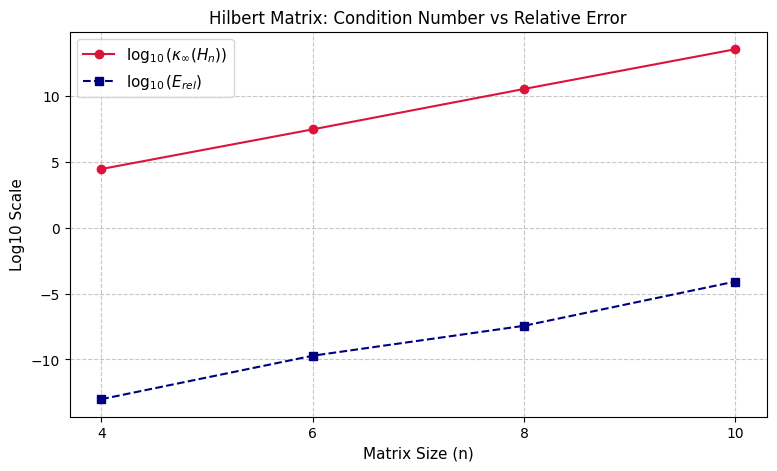

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Sử dụng lại các hàm lu_factorize, forward_substitution, backward_substitution, solve_pivoting, invert_matrix_lu đã định nghĩa ở các phần trước

# Task 7.A: Số điều kiện theo chuẩn vô cùng (Condition Number)
def condition_number_inf(A):
    """
    Tính kappa_inf(A) = ||A||_inf * ||A^(-1)||_inf
    Chuẩn vô cùng ||A||_inf là tổng giá trị tuyệt đối lớn nhất theo hàng.
    """
    A_inv = invert_matrix_lu(A)
    norm_A = np.max(np.sum(np.abs(A), axis=1))
    norm_A_inv = np.max(np.sum(np.abs(A_inv), axis=1))
    return norm_A * norm_A_inv

# Task 7.B: Tạo ma trận Hilbert
def make_hilbert(n):
    """Tạo ma trận Hilbert kích thước n x n với H[i, j] = 1 / (1 + i + j)"""
    return np.fromfunction(lambda i, j: 1.0 / (1.0 + i + j), (n, n))

# Khởi tạo danh sách các giá trị n = 4, 6, 8, 10
n_vals = [4, 6, 8, 10]
cond_list = []
err_list = []

print("=== HILBERT MATRIX ANALYSIS ===")
print(f"{'n':<5} | {'Condition Number (kappa_inf)':<30} | {'Relative Error (E_rel)':<25}")
print("-" * 65)

for n in n_vals:
    # 1. Tạo ma trận Hilbert H_n
    H_n = make_hilbert(n)

    # 2. Đặt nghiệm thực x_true = [1.0, 1.0, ..., 1.0]^T và tính b = H_n @ x_true
    x_true = np.ones(n, dtype=float)
    b = H_n @ x_true

    # 3. Giải hệ H_n @ x = b bằng solve_pivoting
    x_calc = solve_pivoting(H_n, b)

    # 4. Tính số điều kiện kappa_inf và sai số tương đối E_rel
    cond_inf = condition_number_inf(H_n)
    rel_err = np.linalg.norm(x_calc - x_true, 2) / np.linalg.norm(x_true, 2)

    # Lưu kết quả để vẽ đồ thị
    cond_list.append(np.log10(cond_inf))
    err_list.append(np.log10(rel_err))

    print(f"{n:<5d} | {cond_inf:<30.4e} | {rel_err:<25.4e}")

# 5. Vẽ đồ thị so sánh log10(kappa_inf) và log10(E_rel) theo n
plt.figure(figsize=(9, 5))
plt.plot(n_vals, cond_list, 'o-', color='crimson', label=r'$\log_{10}(\kappa_{\infty}(H_n))$')
plt.plot(n_vals, err_list, 's--', color='navy', label=r'$\log_{10}(E_{rel})$')

plt.title("Hilbert Matrix: Condition Number vs Relative Error", fontsize=12)
plt.xlabel("Matrix Size (n)", fontsize=11)
plt.ylabel("Log10 Scale", fontsize=11)
plt.xticks(n_vals)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.show()